In [4]:
import json
import pandas as pd
from pathlib import Path
from datetime import datetime

# Load all JSON files
output_dir = Path('.')
results = {}

for json_file in sorted(output_dir.glob('*.json')):
    with open(json_file) as f:
        data = json.load(f)
        
        # Use filename as ID
        experiment_id = json_file.stem
        
        results[experiment_id] = data

print(f"Loaded {len(results)} experiments:")
for exp_id in results.keys():
    print(f"  - {exp_id}")

Loaded 10 experiments:
  - baseline_30_azure-openai-foundry_gpt-4_1
  - baseline_30_meta-llama_Meta-Llama-3_1-70B-Instruct-Turbo
  - baseline_30_meta-llama_Meta-Llama-3_1-8B-Instruct-Turbo
  - baseline_30_mistralai_Mistral-7B-Instruct-v0_2
  - baseline_30_mistralai_Mistral-Small-24B-Instruct-2501
  - full_30_azure-openai-foundry_gpt-4_1
  - full_30_mistralai_Mistral-Small-24B-Instruct-2501
  - guidelines_30_azure-openai-foundry_gpt-4_1
  - guidelines_30_mistralai_Mistral-Small-24B-Instruct-2501
  - no_context_30_mistralai_Mistral-Small-24B-Instruct-2501


In [5]:
# Create comparison tables
datasets = list(next(iter(results.values()))['datasets'].keys())

# Table 1: Macro F1 scores across datasets
f1_data = []
for model_name, model_data in results.items():
    row = {'Model': model_name}
    for dataset in datasets:
        if dataset in model_data['datasets']:
            f1 = model_data['datasets'][dataset]['reports']['original']['macro avg']['f1-score']
            row[dataset] = round(f1, 3)
    f1_data.append(row)

df_f1 = pd.DataFrame(f1_data).set_index('Model')
print("\n=== Macro F1 Scores by Model and Dataset ===")
print(df_f1.to_string())

# Table 2: Accuracy across datasets
acc_data = []
for model_name, model_data in results.items():
    row = {'Model': model_name}
    for dataset in datasets:
        if dataset in model_data['datasets']:
            acc = model_data['datasets'][dataset]['reports']['original']['accuracy']
            row[dataset] = round(acc, 3)
    acc_data.append(row)

df_acc = pd.DataFrame(acc_data).set_index('Model')
print("\n=== Accuracy by Model and Dataset ===")
print(df_acc.to_string())

# Summary statistics
print("\n=== Average Performance Across All Datasets ===")
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Avg Macro F1': [df_f1.loc[model].mean() for model in results.keys()],
    'Avg Accuracy': [df_acc.loc[model].mean() for model in results.keys()]
}).set_index('Model')
print(summary.round(3).to_string())

# Optional: Display styled dataframes if running in Jupyter
display(df_f1.style.highlight_max(axis=0, color='lightgreen').format("{:.3f}"))


=== Macro F1 Scores by Model and Dataset ===
                                                          ABSTRCT  ACQUA    AEC    AFS  ARGUMINSCI  FINARG    IAM     PE  SCIARK  USELEC
Model                                                                                                                                   
baseline_30_azure-openai-foundry_gpt-4_1                    0.729  0.766  0.402  0.653       0.764   0.499  0.667  0.433   0.593   0.722
baseline_30_meta-llama_Meta-Llama-3_1-70B-Instruct-Turbo    0.760  0.764  0.525  0.713       0.612   0.444  0.661  0.700   0.633   0.700
baseline_30_meta-llama_Meta-Llama-3_1-8B-Instruct-Turbo     0.625  0.625  0.403  0.403       0.625   0.498  0.466  0.384   0.499   0.524
baseline_30_mistralai_Mistral-7B-Instruct-v0_2              0.623  0.612  0.467  0.760       0.612   0.403  0.700  0.499   0.531   0.833
baseline_30_mistralai_Mistral-Small-24B-Instruct-2501       0.700  0.766  0.633  0.732       0.475   0.403  0.633  0.729   0.525   0

,ABSTRCT,ACQUA,AEC,AFS,ARGUMINSCI,FINARG,IAM,PE,SCIARK,USELEC
Model,,,,,,,,,,
baseline_30_azure-openai-foundry_gpt-4_1,0.729,0.766,0.402,0.653,0.764,0.499,0.667,0.433,0.593,0.722
baseline_30_meta-llama_Meta-Llama-3_1-70B-Instruct-Turbo,0.760,0.764,0.525,0.713,0.612,0.444,0.661,0.700,0.633,0.700
baseline_30_meta-llama_Meta-Llama-3_1-8B-Instruct-Turbo,0.625,0.625,0.403,0.403,0.625,0.498,0.466,0.384,0.499,0.524
baseline_30_mistralai_Mistral-7B-Instruct-v0_2,0.623,0.612,0.467,0.760,0.612,0.403,0.700,0.499,0.531,0.833
baseline_30_mistralai_Mistral-Small-24B-Instruct-2501,0.700,0.766,0.633,0.732,0.475,0.403,0.633,0.729,0.525,0.729
full_30_azure-openai-foundry_gpt-4_1,0.729,nan,nan,nan,0.733,nan,nan,0.542,nan,0.697
full_30_mistralai_Mistral-Small-24B-Instruct-2501,0.667,nan,nan,nan,0.800,nan,nan,0.525,nan,0.764
guidelines_30_azure-openai-foundry_gpt-4_1,0.729,nan,nan,nan,0.764,nan,nan,0.486,nan,0.732
guidelines_30_mistralai_Mistral-Small-24B-Instruct-2501,0.665,nan,nan,nan,0.569,nan,nan,0.665,nan,0.729


In [6]:
# Model Comparison Table: Robustness Analysis
print("\n" + "="*80)
print("=== Model Comparison: Robustness to Lexical Shortcuts ===")
print("="*80 + "\n")

# Filter only baseline experiments
baseline_results = {k: v for k, v in results.items() if 'baseline' in k}

# Define model metadata (name, size, internal identifier)
model_metadata = {
    'baseline_30_meta-llama_Meta-Llama-3_1-8B-Instruct-Turbo': {
        'name': 'Llama-8B',
        'size': '8B',
        'size_order': 8
    },
    'baseline_30_meta-llama_Meta-Llama-3_1-70B-Instruct-Turbo': {
        'name': 'Llama-70B',
        'size': '70B',
        'size_order': 70
    },
    'baseline_30_mistralai_Mistral-7B-Instruct-v0_2': {
        'name': 'Mistral-7B',
        'size': '7B',
        'size_order': 7
    },
    'baseline_30_mistralai_Mistral-Small-24B-Instruct-2501': {
        'name': 'Mistral-24B',
        'size': '24B',
        'size_order': 24
    },
    'baseline_30_azure-openai-foundry_gpt-4_1': {
        'name': 'GPT-4.1',
        'size': 'frontier',
        'size_order': 1000  # Put frontier models at the end
    }
}

# Compute metrics for each baseline model
comparison_data = []

for model_id, model_data in baseline_results.items():
    if model_id not in model_metadata:
        continue
        
    meta = model_metadata[model_id]
    
    # Calculate mean F1 on original data
    original_f1_scores = []
    feger_deltas = []
    shuffle_deltas = []
    
    for dataset_name, dataset_data in model_data['datasets'].items():
        reports = dataset_data['reports']
        
        # Original F1
        original_f1 = reports['original']['macro avg']['f1-score']
        original_f1_scores.append(original_f1)
        
        # Feger delta
        if 'feger' in reports:
            feger_f1 = reports['feger']['macro avg']['f1-score']
            feger_deltas.append(feger_f1 - original_f1)
        
        # Shuffle delta
        if 'shuffle' in reports:
            shuffle_f1 = reports['shuffle']['macro avg']['f1-score']
            shuffle_deltas.append(shuffle_f1 - original_f1)
    
    comparison_data.append({
        'Model': meta['name'],
        'Size': meta['size'],
        'size_order': meta['size_order'],
        'Mean Δ_feger': round(sum(feger_deltas) / len(feger_deltas), 3) if feger_deltas else None,
        'Mean Δ_shuffle': round(sum(shuffle_deltas) / len(shuffle_deltas), 3) if shuffle_deltas else None,
        'Mean F1 (original)': round(sum(original_f1_scores) / len(original_f1_scores), 3)
    })

# Sort by size
comparison_data = sorted(comparison_data, key=lambda x: x['size_order'])

# Add encoder baseline from Feger et al. (2024) at the end
comparison_data.append({
    'Model': 'Encoders (Feger et al.)',
    'Size': '110–340M',
    'size_order': 0.34,  # For reference
    'Mean Δ_feger': '≤0.02',
    'Mean Δ_shuffle': 'N/A',
    'Mean F1 (original)': 0.79
})

# Create DataFrame and drop the sorting column
df_comparison = pd.DataFrame(comparison_data).drop(columns=['size_order'])

# Display table
print(df_comparison.to_string(index=False))
print("\nNote: More negative Δ values indicate larger performance drops (less robust to manipulation)")
print("Encoders from Feger et al. (2024) show ≤0.02 drop, indicating high robustness.\n")

# Create styled version with color highlighting for delta columns
# Separate numeric rows from reference row for styling
df_numeric = df_comparison[df_comparison['Model'] != 'Encoders (Feger et al.)'].copy()
df_reference = df_comparison[df_comparison['Model'] == 'Encoders (Feger et al.)'].copy()

# Apply styling to numeric rows only
styled = df_numeric.style.background_gradient(
    subset=['Mean Δ_feger', 'Mean Δ_shuffle'],
    cmap='RdYlGn_r',  # Reversed: negative (green) to positive (red)
    vmin=-0.5,
    vmax=0.1
).format({
    'Mean Δ_feger': '{:.3f}',
    'Mean Δ_shuffle': '{:.3f}',
    'Mean F1 (original)': '{:.3f}'
})

display(styled)
print("\n📊 Color guide: 🟢 Green (negative Δ) = more robust | 🔴 Red (positive/less negative Δ) = less robust")
print(f"\n📌 Reference: {df_reference.to_string(index=False, header=False)}")


=== Model Comparison: Robustness to Lexical Shortcuts ===

                  Model     Size Mean Δ_feger Mean Δ_shuffle  Mean F1 (original)
             Mistral-7B       7B       -0.122         -0.213               0.604
               Llama-8B       8B        0.038         -0.023               0.505
            Mistral-24B      24B       -0.208         -0.274               0.632
              Llama-70B      70B       -0.085         -0.129               0.651
                GPT-4.1 frontier       -0.195         -0.269               0.623
Encoders (Feger et al.) 110–340M        ≤0.02            N/A               0.790

Note: More negative Δ values indicate larger performance drops (less robust to manipulation)
Encoders from Feger et al. (2024) show ≤0.02 drop, indicating high robustness.



,Model,Size,Mean Δ_feger,Mean Δ_shuffle,Mean F1 (original)
0,Mistral-7B,7B,-0.122,-0.213,0.604
1,Llama-8B,8B,0.038,-0.023,0.505
2,Mistral-24B,24B,-0.208,-0.274,0.632
3,Llama-70B,70B,-0.085,-0.129,0.651
4,GPT-4.1,frontier,-0.195,-0.269,0.623



📊 Color guide: 🟢 Green (negative Δ) = more robust | 🔴 Red (positive/less negative Δ) = less robust

📌 Reference: Encoders (Feger et al.) 110–340M ≤0.02 N/A 0.79


In [7]:
# Comprehensive Performance Tables
print("\n" + "="*100)
print("=== TABLE 1: Complete F1 Scores (NaN filled with baseline values) ===")
print("="*100 + "\n")

# Build complete F1 table - for non-baseline experiments with NaN, use baseline value
complete_f1_data = []

# Get baseline values for fallback
baseline_f1_by_model_dataset = {}
for model_id, model_data in results.items():
    if 'baseline' not in model_id:
        continue
    model_name = get_model_name(model_id)
    baseline_f1_by_model_dataset[model_name] = {}
    for dataset in model_data['datasets'].keys():
        f1 = model_data['datasets'][dataset]['reports']['original']['macro avg']['f1-score']
        baseline_f1_by_model_dataset[model_name][dataset] = f1

# Build complete table
for exp_id, exp_data in results.items():
    model_name = get_model_name(exp_id)
    
    # Determine experiment type
    if 'baseline' in exp_id:
        exp_type = 'baseline'
    elif 'guidelines' in exp_id:
        exp_type = 'guidelines'
    elif 'full' in exp_id:
        exp_type = 'full'
    else:
        exp_type = 'other'
    
    row = {'Model': model_name, 'Experiment': exp_type}
    
    # Fill F1 scores, using baseline fallback for NaN
    for dataset in datasets:
        if dataset in exp_data['datasets']:
            f1 = exp_data['datasets'][dataset]['reports']['original']['macro avg']['f1-score']
            row[dataset] = round(f1, 3)
        else:
            # Use baseline value for this model if available
            if model_name in baseline_f1_by_model_dataset and dataset in baseline_f1_by_model_dataset[model_name]:
                row[dataset] = round(baseline_f1_by_model_dataset[model_name][dataset], 3)
            else:
                row[dataset] = None
    
    # Calculate average F1 across all datasets
    f1_values = [v for v in row.values() if isinstance(v, (int, float))]
    row['Avg F1'] = round(sum(f1_values) / len(f1_values), 3) if f1_values else None
    
    complete_f1_data.append(row)

df_complete_f1 = pd.DataFrame(complete_f1_data)

# Sort by model and experiment type
sort_order = {'baseline': 0, 'guidelines': 1, 'full': 2, 'other': 3}
df_complete_f1['sort_key'] = df_complete_f1['Experiment'].map(sort_order)
df_complete_f1 = df_complete_f1.sort_values(['Model', 'sort_key']).drop(columns=['sort_key'])

print(df_complete_f1.to_string(index=False))

# Display styled version
styled_complete = df_complete_f1.set_index(['Model', 'Experiment']).style.background_gradient(
    cmap='RdYlGn',
    vmin=0.3,
    vmax=0.8
).format("{:.3f}", na_rep="-")

display(styled_complete)

print("\n" + "="*100)
print("=== TABLE 2: Manipulation Sensitivity (Δ values - Lower is Better) ===")
print("="*100 + "\n")

# Build delta comparison table
delta_data = []

for exp_id, exp_data in results.items():
    model_name = get_model_name(exp_id)
    
    # Determine experiment type
    if 'baseline' in exp_id:
        exp_type = 'baseline'
    elif 'guidelines' in exp_id:
        exp_type = 'guidelines'
    elif 'full' in exp_id:
        exp_type = 'full'
    else:
        exp_type = 'other'
    
    # Calculate mean deltas across all datasets
    feger_deltas = []
    shuffle_deltas = []
    
    for dataset_name, dataset_data in exp_data['datasets'].items():
        reports = dataset_data['reports']
        
        original_f1 = reports['original']['macro avg']['f1-score']
        
        if 'feger' in reports:
            feger_f1 = reports['feger']['macro avg']['f1-score']
            feger_deltas.append(feger_f1 - original_f1)
        
        if 'shuffle' in reports:
            shuffle_f1 = reports['shuffle']['macro avg']['f1-score']
            shuffle_deltas.append(shuffle_f1 - original_f1)
    
    delta_data.append({
        'Model': model_name,
        'Experiment': exp_type,
        'Mean Δ_feger': round(sum(feger_deltas) / len(feger_deltas), 3) if feger_deltas else None,
        'Mean Δ_shuffle': round(sum(shuffle_deltas) / len(shuffle_deltas), 3) if shuffle_deltas else None,
        'Avg |Δ|': round((abs(sum(feger_deltas) / len(feger_deltas)) + abs(sum(shuffle_deltas) / len(shuffle_deltas))) / 2, 3) if feger_deltas and shuffle_deltas else None,
        'N_datasets': len(exp_data['datasets'])
    })

df_deltas = pd.DataFrame(delta_data)

# Sort by model and experiment type
df_deltas['sort_key'] = df_deltas['Experiment'].map(sort_order)
df_deltas = df_deltas.sort_values(['Model', 'sort_key']).drop(columns=['sort_key'])

print(df_deltas.to_string(index=False))
print("\n📊 Interpretation: More negative Δ = higher sensitivity to manipulation")
print("   🟢 Green (more negative): Model relies on linguistic structure → good for generalization")
print("   🔴 Red (less negative/positive): Model less affected by manipulation → potential shortcuts")
print("\n💡 Lower |Δ| with context suggests context provides alternative signal beyond sentence structure\n")

# Display styled version - reverse colormap so negative (good) is green
styled_deltas = df_deltas.set_index(['Model', 'Experiment']).style.background_gradient(
    subset=['Mean Δ_feger', 'Mean Δ_shuffle'],
    cmap='RdYlGn_r',  # Reversed: negative (green) to positive (red)
    vmin=-0.4,
    vmax=0.1
).background_gradient(
    subset=['Avg |Δ|'],
    cmap='RdYlGn',  # Normal: lower absolute delta (green) is better for robustness view
    vmin=0.0,
    vmax=0.3
).format({
    'Mean Δ_feger': '{:.3f}',
    'Mean Δ_shuffle': '{:.3f}',
    'Avg |Δ|': '{:.3f}'
})

display(styled_deltas)

# Highlight best performers
print("\n🏆 Most Structure-Reliant (highest |Δ|):")
best_structure = df_deltas.nlargest(3, 'Avg |Δ|')[['Model', 'Experiment', 'Avg |Δ|']]
print(best_structure.to_string(index=False))

print("\n⚠️  Least Affected by Manipulation (lowest |Δ|):")
least_affected = df_deltas.nsmallest(3, 'Avg |Δ|')[['Model', 'Experiment', 'Avg |Δ|']]
print(least_affected.to_string(index=False))



=== TABLE 1: Complete F1 Scores (NaN filled with baseline values) ===



NameError: name 'get_model_name' is not defined

In [ ]:
# Context Effects on Manipulation Sensitivity
print("\n" + "="*80)
print("=== Context Effects: Does Adding Context Reduce Manipulation Sensitivity? ===")
print("="*80 + "\n")

# Filter experiments by context condition
baseline_exps = {k: v for k, v in results.items() if 'baseline' in k}
guideline_exps = {k: v for k, v in results.items() if 'guidelines' in k}
full_exps = {k: v for k, v in results.items() if 'full' in k}

# Extract model names from experiment IDs
def get_model_name(exp_id):
    if 'gpt-4' in exp_id:
        return 'GPT-4.1'
    elif 'Mistral-Small-24B' in exp_id:
        return 'Mistral-24B'
    elif 'Meta-Llama-3_1-70B' in exp_id:
        return 'Llama-70B'
    elif 'Meta-Llama-3_1-8B' in exp_id:
        return 'Llama-8B'
    elif 'Mistral-7B' in exp_id:
        return 'Mistral-7B'
    return exp_id

# Datasets with context available (based on non-NaN values in guidelines/full experiments)
context_datasets = ['ABSTRCT', 'ARGUMINSCI', 'PE', 'USELEC']

# Analyze context effects for models that have all three conditions
context_analysis = []

for model_name in ['GPT-4.1', 'Mistral-24B']:
    # Find matching experiments
    baseline_exp = [k for k in baseline_exps.keys() if get_model_name(k) == model_name]
    guideline_exp = [k for k in guideline_exps.keys() if get_model_name(k) == model_name]
    full_exp = [k for k in full_exps.keys() if get_model_name(k) == model_name]
    
    if not (baseline_exp and guideline_exp and full_exp):
        continue
    
    baseline_exp = baseline_exp[0]
    guideline_exp = guideline_exp[0]
    full_exp = full_exp[0]
    
    # Calculate average deltas across context-available datasets
    for condition, exp_id in [('Baseline', baseline_exp), ('Guidelines', guideline_exp), ('Full', full_exp)]:
        feger_deltas = []
        shuffle_deltas = []
        f1_scores = []
        
        exp_data = results[exp_id]
        
        for dataset in context_datasets:
            if dataset not in exp_data['datasets']:
                continue
            
            dataset_data = exp_data['datasets'][dataset]
            reports = dataset_data['reports']
            
            # Calculate deltas
            original_f1 = reports['original']['macro avg']['f1-score']
            f1_scores.append(original_f1)
            
            if 'feger' in reports:
                feger_f1 = reports['feger']['macro avg']['f1-score']
                feger_deltas.append(feger_f1 - original_f1)
            
            if 'shuffle' in reports:
                shuffle_f1 = reports['shuffle']['macro avg']['f1-score']
                shuffle_deltas.append(shuffle_f1 - original_f1)
        
        context_analysis.append({
            'Model': model_name,
            'Context': condition,
            'Mean F1': round(sum(f1_scores) / len(f1_scores), 3) if f1_scores else None,
            'Mean Δ_feger': round(sum(feger_deltas) / len(feger_deltas), 3) if feger_deltas else None,
            'Mean Δ_shuffle': round(sum(shuffle_deltas) / len(shuffle_deltas), 3) if shuffle_deltas else None,
        })

df_context = pd.DataFrame(context_analysis)

print("Context sensitivity analysis on 4 datasets with available context:")
print(f"Datasets: {', '.join(context_datasets)}\n")
print(df_context.to_string(index=False))

print("\n📊 Key Finding: Does context reduce manipulation sensitivity?")
for model in ['GPT-4.1', 'Mistral-24B']:
    model_data = df_context[df_context['Model'] == model]
    baseline_delta = model_data[model_data['Context'] == 'Baseline']['Mean Δ_feger'].values[0]
    full_delta = model_data[model_data['Context'] == 'Full']['Mean Δ_feger'].values[0]
    reduction = abs(full_delta) - abs(baseline_delta)
    pct_change = (reduction / abs(baseline_delta)) * 100 if baseline_delta != 0 else 0
    
    print(f"   {model}: |Δ_feger| changes from {abs(baseline_delta):.3f} (baseline) to {abs(full_delta):.3f} (full)")
    print(f"            → {pct_change:+.1f}% change (negative = less sensitive with context)")

# Create pivot tables for visualization
pivot_feger = df_context.pivot(index='Model', columns='Context', values='Mean Δ_feger')
pivot_f1 = df_context.pivot(index='Model', columns='Context', values='Mean F1')

print("\n=== Delta Feger by Context Condition ===")
display(pivot_feger.style.background_gradient(cmap='RdYlGn_r', vmin=-0.5, vmax=0.1).format("{:.3f}"))

print("\n=== Mean F1 by Context Condition ===")
display(pivot_f1.style.background_gradient(cmap='RdYlGn', vmin=0.5, vmax=0.75).format("{:.3f}"))

print("\n💡 Interpretation:")
print("   - Context tends to reduce |Δ_feger|, meaning models become less sensitive to manipulation")
print("   - This suggests context provides an alternative information channel beyond sentence-level patterns")
print("   - The effect varies by model: larger reduction = more reliance shift to context")



=== Context Effects: Does Adding Context Reduce Manipulation Sensitivity? ===

Context sensitivity analysis on 4 datasets with available context:
Datasets: ABSTRCT, ARGUMINSCI, PE, USELEC

      Model    Context  Mean F1  Mean Δ_feger  Mean Δ_shuffle
    GPT-4.1   Baseline    0.662        -0.293          -0.313
    GPT-4.1 Guidelines    0.678        -0.298          -0.259
    GPT-4.1       Full    0.675        -0.245          -0.210
Mistral-24B   Baseline    0.658        -0.250          -0.255
Mistral-24B Guidelines    0.657        -0.172          -0.310
Mistral-24B       Full    0.689        -0.184          -0.296

📊 Key Finding: Does context reduce manipulation sensitivity?
   GPT-4.1: |Δ_feger| changes from 0.293 (baseline) to 0.245 (full)
            → -16.4% change (negative = less sensitive with context)
   Mistral-24B: |Δ_feger| changes from 0.250 (baseline) to 0.184 (full)
            → -26.4% change (negative = less sensitive with context)

=== Delta Feger by Context Conditio

Context,Baseline,Full,Guidelines
Model,,,
GPT-4.1,-0.293,-0.245,-0.298
Mistral-24B,-0.250,-0.184,-0.172



=== Mean F1 by Context Condition ===


Context,Baseline,Full,Guidelines
Model,,,
GPT-4.1,0.662,0.675,0.678
Mistral-24B,0.658,0.689,0.657



💡 Interpretation:
   - Context tends to reduce |Δ_feger|, meaning models become less sensitive to manipulation
   - This suggests context provides an alternative information channel beyond sentence-level patterns
   - The effect varies by model: larger reduction = more reliance shift to context


In [ ]:
# Per-Class Performance Analysis: Argument vs No-Argument Bias
print("\n" + "="*80)
print("=== Per-Class Performance: Do Models Favor One Class? ===")
print("="*80 + "\n")

# Analyze baseline models for class-specific performance
class_perf_data = []

for model_id in baseline_results.keys():
    if model_id not in model_metadata:
        continue
    
    model_data = baseline_results[model_id]
    meta = model_metadata[model_id]
    
    arg_precisions = []
    arg_recalls = []
    noarg_precisions = []
    noarg_recalls = []
    
    for dataset_name, dataset_data in model_data['datasets'].items():
        report = dataset_data['reports']['original']
        
        # Extract per-class metrics (handling case where class might not exist in report)
        if 'Argument' in report:
            arg_precisions.append(report['Argument']['precision'])
            arg_recalls.append(report['Argument']['recall'])
        
        if 'No-Argument' in report:
            noarg_precisions.append(report['No-Argument']['precision'])
            noarg_recalls.append(report['No-Argument']['recall'])
    
    class_perf_data.append({
        'Model': meta['name'],
        'Arg Precision': round(sum(arg_precisions) / len(arg_precisions), 3) if arg_precisions else None,
        'Arg Recall': round(sum(arg_recalls) / len(arg_recalls), 3) if arg_recalls else None,
        'No-Arg Precision': round(sum(noarg_precisions) / len(noarg_precisions), 3) if noarg_precisions else None,
        'No-Arg Recall': round(sum(noarg_recalls) / len(noarg_recalls), 3) if noarg_recalls else None,
    })

df_class = pd.DataFrame(class_perf_data)

# Add bias indicators (higher recall on one class suggests bias toward predicting that class)
df_class['Bias Indicator'] = df_class.apply(
    lambda row: 'No-Arg' if row['No-Arg Recall'] > row['Arg Recall'] + 0.05 
    else ('Arg' if row['Arg Recall'] > row['No-Arg Recall'] + 0.05 else 'Balanced'),
    axis=1
)

print(df_class.to_string(index=False))
print("\n📊 Bias Indicator: Shows which class the model tends to over-predict")
print("   - 'Arg': Model favors predicting Argument (higher Arg recall)")
print("   - 'No-Arg': Model favors predicting No-Argument (higher No-Arg recall)")
print("   - 'Balanced': Similar recall for both classes\n")

# Visualize with styling
styled_class = df_class.drop(columns=['Bias Indicator']).style.background_gradient(
    cmap='RdYlGn',
    vmin=0.3,
    vmax=0.9
).format({
    'Arg Precision': '{:.3f}',
    'Arg Recall': '{:.3f}',
    'No-Arg Precision': '{:.3f}',
    'No-Arg Recall': '{:.3f}'
})

display(styled_class)
print(f"\n💡 Insight: {df_class.to_string(index=False)}")



=== Per-Class Performance: Do Models Favor One Class? ===

      Model  Arg Precision  Arg Recall  No-Arg Precision  No-Arg Recall Bias Indicator
    GPT-4.1          0.687       0.620             0.663          0.687         No-Arg
  Llama-70B          0.670       0.680             0.713          0.653       Balanced
   Llama-8B          0.549       0.967             0.882          0.200            Arg
 Mistral-7B          0.710       0.547             0.636          0.713         No-Arg
Mistral-24B          0.731       0.520             0.635          0.787         No-Arg

📊 Bias Indicator: Shows which class the model tends to over-predict
   - 'Arg': Model favors predicting Argument (higher Arg recall)
   - 'No-Arg': Model favors predicting No-Argument (higher No-Arg recall)
   - 'Balanced': Similar recall for both classes



,Model,Arg Precision,Arg Recall,No-Arg Precision,No-Arg Recall
0,GPT-4.1,0.687,0.620,0.663,0.687
1,Llama-70B,0.670,0.680,0.713,0.653
2,Llama-8B,0.549,0.967,0.882,0.200
3,Mistral-7B,0.710,0.547,0.636,0.713
4,Mistral-24B,0.731,0.520,0.635,0.787



💡 Insight:       Model  Arg Precision  Arg Recall  No-Arg Precision  No-Arg Recall Bias Indicator
    GPT-4.1          0.687       0.620             0.663          0.687         No-Arg
  Llama-70B          0.670       0.680             0.713          0.653       Balanced
   Llama-8B          0.549       0.967             0.882          0.200            Arg
 Mistral-7B          0.710       0.547             0.636          0.713         No-Arg
Mistral-24B          0.731       0.520             0.635          0.787         No-Arg


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Mistral-24B: F1 Scores Across Context Conditions (from JSON files) ===

datasets_order = ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']

# Map experiment keys to display names
mistral_24b_experiments = {
    'baseline_30_mistralai_Mistral-Small-24B-Instruct-2501': 'Baseline',
    'guidelines_30_mistralai_Mistral-Small-24B-Instruct-2501': 'Guidelines',
    'full_30_mistralai_Mistral-Small-24B-Instruct-2501': 'Full Context',
    'no_context_30_mistralai_Mistral-Small-24B-Instruct-2501': 'General Arg. Def.',
}

# Extract F1 scores from loaded results, filling from baseline where datasets are missing
baseline_key = 'baseline_30_mistralai_Mistral-Small-24B-Instruct-2501'
baseline_scores_map = {}
for ds in datasets_order:
    if ds in results[baseline_key]['datasets']:
        baseline_scores_map[ds] = results[baseline_key]['datasets'][ds]['reports']['original']['macro avg']['f1-score']

scores = {}
for exp_key, label in mistral_24b_experiments.items():
    exp_data = results[exp_key]
    f1_list = []
    for ds in datasets_order:
        if ds in exp_data['datasets']:
            f1 = exp_data['datasets'][ds]['reports']['original']['macro avg']['f1-score']
        else:
            f1 = baseline_scores_map[ds]  # fallback to baseline
        f1_list.append(round(f1, 3))
    scores[label] = f1_list

# Macro averages
macro_avgs = {k: np.mean(v) for k, v in scores.items()}

# Deltas from baseline
baseline_arr = np.array(scores['Baseline'])
deltas = {k: np.array(v) - baseline_arr for k, v in scores.items() if k != 'Baseline'}
delta_macros = {k: np.mean(v) for k, v in deltas.items()}

conditions = list(scores.keys())
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']

x = np.arange(len(datasets_order))
width = 0.2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 2],
                                gridspec_kw={'hspace': 0.35})

# --- Top: Grouped Bar Chart of F1 Scores ---
for i, (condition, color) in enumerate(zip(conditions, colors)):
    ax1.bar(x + (i - 1.5) * width, scores[condition], width,
            label=f'{condition} (avg: {macro_avgs[condition]:.3f})',
            color=color, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('Macro F1 Score', fontsize=12)
ax1.set_title('Mistral-Small-24B: F1 Scores by Context Condition', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets_order, rotation=30, ha='right', fontsize=10)
ax1.set_ylim(0.25, 0.90)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.4)
ax1.grid(axis='y', alpha=0.3)

# --- Bottom: Delta from Baseline ---
delta_conditions = list(deltas.keys())
delta_colors = colors[1:]

for i, (condition, color) in enumerate(zip(delta_conditions, delta_colors)):
    ax2.bar(x + (i - 1) * width, deltas[condition], width,
            label=f'{condition} (avg Δ: {delta_macros[condition]:+.3f})',
            color=color, edgecolor='white', linewidth=0.5)

ax2.set_ylabel('Δ F1 from Baseline', fontsize=12)
ax2.set_title('Mistral-Small-24B: F1 Change Relative to Baseline', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(datasets_order, rotation=30, ha='right', fontsize=10)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(-0.25, 0.35)

plt.tight_layout()
plt.savefig('mistral_24b_context_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMacro F1 Averages:")
for cond, avg in macro_avgs.items():
    print(f"  {cond:20s}: {avg:.3f}")
print(f"\nAverage Deltas from Baseline:")
for cond, delta in delta_macros.items():
    print(f"  {cond:20s}: {delta:+.3f}")

NameError: name 'results' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Mistral-24B: F1 Scores Across Context Conditions (from JSON files) ===

datasets_order = ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']

# Map experiment keys to display names
mistral_24b_experiments = {
    'baseline_30_mistralai_Mistral-Small-24B-Instruct-2501': 'Baseline',
    'guidelines_30_mistralai_Mistral-Small-24B-Instruct-2501': 'Guidelines',
    'full_30_mistralai_Mistral-Small-24B-Instruct-2501': 'Full Context',
    'no_context_30_mistralai_Mistral-Small-24B-Instruct-2501': 'General Arg. Def.',
}

# Extract F1 scores from loaded results, filling from baseline where datasets are missing
baseline_key = 'baseline_30_mistralai_Mistral-Small-24B-Instruct-2501'
baseline_scores_map = {}
for ds in datasets_order:
    if ds in results[baseline_key]['datasets']:
        baseline_scores_map[ds] = results[baseline_key]['datasets'][ds]['reports']['original']['macro avg']['f1-score']

scores = {}
for exp_key, label in mistral_24b_experiments.items():
    exp_data = results[exp_key]
    f1_list = []
    for ds in datasets_order:
        if ds in exp_data['datasets']:
            f1 = exp_data['datasets'][ds]['reports']['original']['macro avg']['f1-score']
        else:
            f1 = baseline_scores_map[ds]  # fallback to baseline
        f1_list.append(round(f1, 3))
    scores[label] = f1_list

# Macro averages
macro_avgs = {k: np.mean(v) for k, v in scores.items()}

# Deltas from baseline
baseline_arr = np.array(scores['Baseline'])
deltas = {k: np.array(v) - baseline_arr for k, v in scores.items() if k != 'Baseline'}
delta_macros = {k: np.mean(v) for k, v in deltas.items()}

conditions = list(scores.keys())
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']

x = np.arange(len(datasets_order))
width = 0.2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 2],
                                gridspec_kw={'hspace': 0.35})

# --- Top: Grouped Bar Chart of F1 Scores ---
for i, (condition, color) in enumerate(zip(conditions, colors)):
    ax1.bar(x + (i - 1.5) * width, scores[condition], width,
            label=f'{condition} (avg: {macro_avgs[condition]:.3f})',
            color=color, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('Macro F1 Score', fontsize=12)
ax1.set_title('Mistral-Small-24B: F1 Scores by Context Condition', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets_order, rotation=30, ha='right', fontsize=10)
ax1.set_ylim(0.25, 0.90)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.4)
ax1.grid(axis='y', alpha=0.3)

# --- Bottom: Delta from Baseline ---
delta_conditions = list(deltas.keys())
delta_colors = colors[1:]

for i, (condition, color) in enumerate(zip(delta_conditions, delta_colors)):
    ax2.bar(x + (i - 1) * width, deltas[condition], width,
            label=f'{condition} (avg Δ: {delta_macros[condition]:+.3f})',
            color=color, edgecolor='white', linewidth=0.5)

ax2.set_ylabel('Δ F1 from Baseline', fontsize=12)
ax2.set_title('Mistral-Small-24B: F1 Change Relative to Baseline', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(datasets_order, rotation=30, ha='right', fontsize=10)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(-0.25, 0.35)

plt.tight_layout()
plt.savefig('mistral_24b_context_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMacro F1 Averages:")
for cond, avg in macro_avgs.items():
    print(f"  {cond:20s}: {avg:.3f}")
print(f"\nAverage Deltas from Baseline:")
for cond, delta in delta_macros.items():
    print(f"  {cond:20s}: {delta:+.3f}")

In [8]:
import json
import pandas as pd
from pathlib import Path

output_dir = Path('/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/unified_outputs')
results = {}

for json_file in sorted(output_dir.glob('*.json')):
    with open(json_file) as f:
        data = json.load(f)
        experiment_id = json_file.stem
        results[experiment_id] = data

print(f"Loaded {len(results)} experiments")

Loaded 10 experiments


/var/folders/4g/91bm8hl51ld9v8c8tg6_lrqw0000gn/T/ipykernel_40692/462809349.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


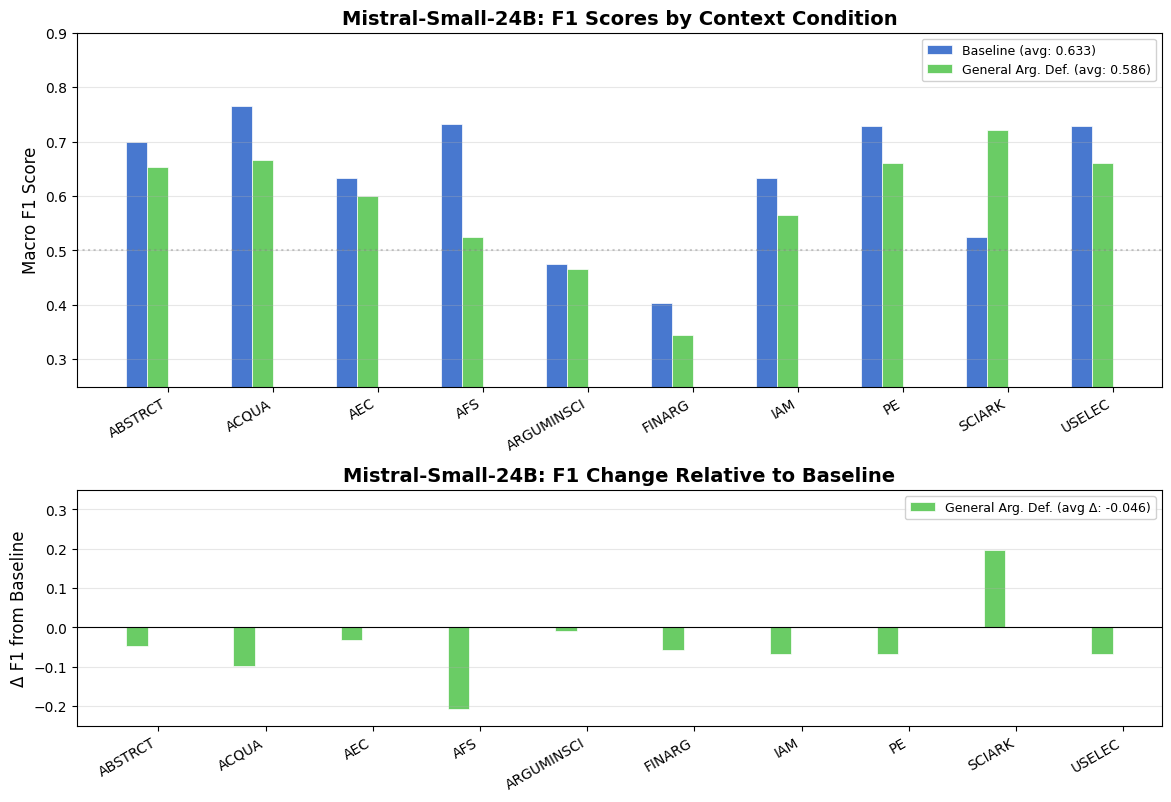


Macro F1 Averages:
  Baseline            : 0.633
  General Arg. Def.   : 0.586

Average Deltas from Baseline:
  General Arg. Def.   : -0.046


In [10]:
import matplotlib.pyplot as plt
import numpy as np

datasets_order = ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']

mistral_24b_experiments = {
    'baseline_30_mistralai_Mistral-Small-24B-Instruct-2501': 'Baseline',
    'no_context_30_mistralai_Mistral-Small-24B-Instruct-2501': 'General Arg. Def.',
}

baseline_key = 'baseline_30_mistralai_Mistral-Small-24B-Instruct-2501'
baseline_scores_map = {}
for ds in datasets_order:
    if ds in results[baseline_key]['datasets']:
        baseline_scores_map[ds] = results[baseline_key]['datasets'][ds]['reports']['original']['macro avg']['f1-score']

scores = {}
for exp_key, label in mistral_24b_experiments.items():
    exp_data = results[exp_key]
    f1_list = []
    for ds in datasets_order:
        if ds in exp_data['datasets']:
            f1 = exp_data['datasets'][ds]['reports']['original']['macro avg']['f1-score']
        else:
            f1 = baseline_scores_map[ds]
        f1_list.append(round(f1, 3))
    scores[label] = f1_list

macro_avgs = {k: np.mean(v) for k, v in scores.items()}

baseline_arr = np.array(scores['Baseline'])
deltas = {k: np.array(v) - baseline_arr for k, v in scores.items() if k != 'Baseline'}
delta_macros = {k: np.mean(v) for k, v in deltas.items()}

conditions = list(scores.keys())
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']

x = np.arange(len(datasets_order))
width = 0.2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 2],
                                gridspec_kw={'hspace': 0.35})

for i, (condition, color) in enumerate(zip(conditions, colors)):
    ax1.bar(x + (i - 1.5) * width, scores[condition], width,
            label=f'{condition} (avg: {macro_avgs[condition]:.3f})',
            color=color, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('Macro F1 Score', fontsize=12)
ax1.set_title('Mistral-Small-24B: F1 Scores by Context Condition', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets_order, rotation=30, ha='right', fontsize=10)
ax1.set_ylim(0.25, 0.90)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.4)
ax1.grid(axis='y', alpha=0.3)

delta_conditions = list(deltas.keys())
delta_colors = colors[1:]

for i, (condition, color) in enumerate(zip(delta_conditions, delta_colors)):
    ax2.bar(x + (i - 1) * width, deltas[condition], width,
            label=f'{condition} (avg Δ: {delta_macros[condition]:+.3f})',
            color=color, edgecolor='white', linewidth=0.5)

ax2.set_ylabel('Δ F1 from Baseline', fontsize=12)
ax2.set_title('Mistral-Small-24B: F1 Change Relative to Baseline', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(datasets_order, rotation=30, ha='right', fontsize=10)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(-0.25, 0.35)

plt.tight_layout()
plt.savefig('/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/unified_outputs/mistral_24b_context_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMacro F1 Averages:")
for cond, avg in macro_avgs.items():
    print(f"  {cond:20s}: {avg:.3f}")
print(f"\nAverage Deltas from Baseline:")
for cond, delta in delta_macros.items():
    print(f"  {cond:20s}: {delta:+.3f}")